In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import os

NOTEBOOK_DIR = Path(os.path.abspath('')).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]
PAPER_ROOT = PROJECT_ROOT.parent / 'Matryoshka'

sys.path.insert(0, str(PROJECT_ROOT / 'experiments'))
import plots_style
plots_style.apply_style()

df = pd.read_csv(NOTEBOOK_DIR / 'logs' / 'proxy_fidelity_results.csv')
df.head()


,proxy_f1,downstream_f1,step,n_augmented_features,n_total_features,table,task,experiment,proxy_mse,downstream_mse
0,0.518632,0.516140,0,0,6,arrest,classification,cuk_arrest_forward,NaN,NaN
1,0.519134,0.515883,1,1,7,arrest,classification,cuk_arrest_forward,NaN,NaN
2,0.519135,0.515830,2,2,8,arrest,classification,cuk_arrest_forward,NaN,NaN
3,0.518798,0.515852,3,3,9,arrest,classification,cuk_arrest_forward,NaN,NaN
4,0.519449,0.515779,4,4,10,arrest,classification,cuk_arrest_forward,NaN,NaN


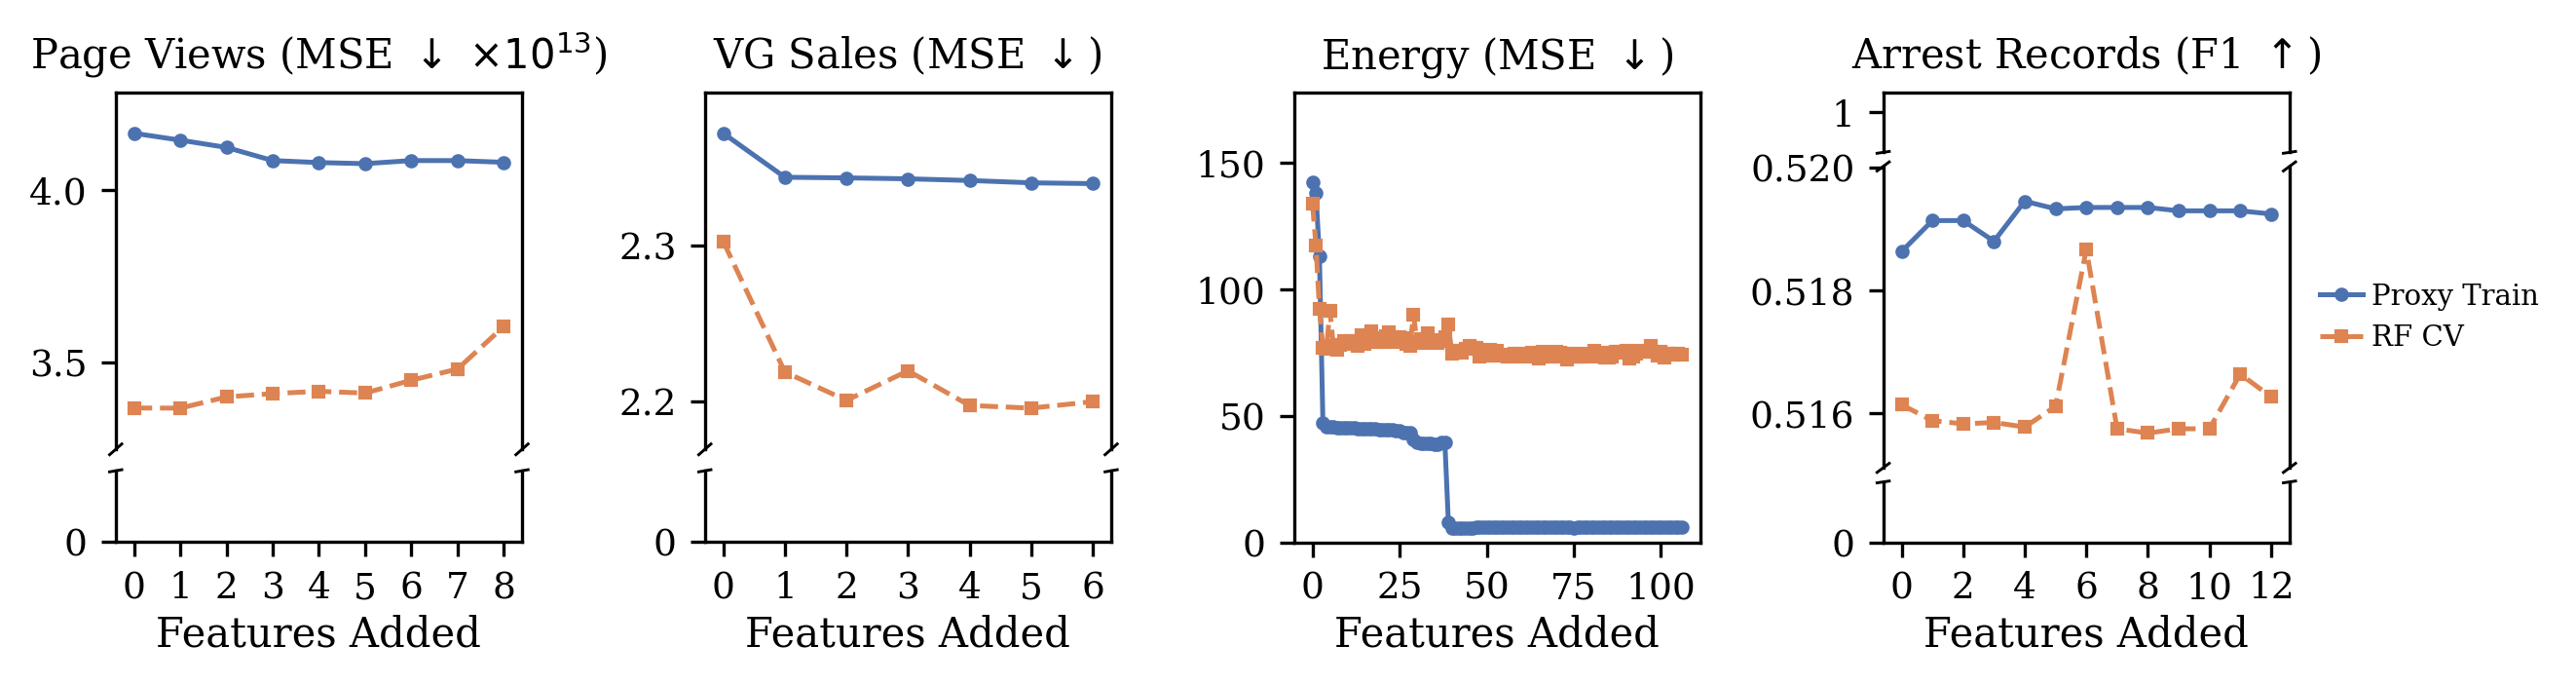

In [3]:

# ── Per-dataset plots: proxy train score & downstream CV score ───────
from matplotlib.ticker import MaxNLocator, MultipleLocator
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

DISPLAY_NAMES = {
    'energy': 'Energy', 'pageviews': 'Page Views', 'vgsales': 'VG Sales',
    'arrest': 'Arrest Records', 'hospital': 'Hospital', 'trees': 'Street Trees',
    'realestate': 'Real Estate', 'food': 'Food Facts',
}

VALUE_SCALE = {'pageviews': (1e13, '$\\times 10^{13}$')}

experiments = df['experiment'].unique()
regression_exps = df[df['task'] == 'regression']['experiment'].unique()
classification_exps = df[df['task'] == 'classification']['experiment'].unique()

n_reg = len(regression_exps)
n_cls = len(classification_exps)
n_total = n_reg + n_cls
ordered_exps = list(regression_exps) + list(classification_exps)

fig = plt.figure(figsize=(2.4 * n_total, 2.0))
outer_gs = GridSpec(1, n_total, figure=fig, wspace=0.45)

def draw_break_marks(ax_top, ax_bot, d=0.015):
    kwargs = dict(color='k', clip_on=False, linewidth=0.7)
    ax_top.plot((-d, +d), (-d, +d), transform=ax_top.transAxes, **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), transform=ax_top.transAxes, **kwargs)
    ax_bot.plot((-d, +d), (1 - d, 1 + d), transform=ax_bot.transAxes, **kwargs)
    ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), transform=ax_bot.transAxes, **kwargs)

def set_x_ticks(ax, table):
    if table == 'energy':
        ax.xaxis.set_major_locator(MultipleLocator(25))
    else:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

last_legend_ax = None  # will hold the axis from the last panel for the shared legend

for idx, exp in enumerate(ordered_exps):
    sub = df[df['experiment'] == exp].sort_values('step')
    table = sub.iloc[0]['table']
    task = sub.iloc[0]['task']
    x = sub['n_augmented_features'].values

    if task == 'regression':
        proxy_vals = sub['proxy_mse'].values.copy()
        ds_vals = sub['downstream_mse'].values.copy()
        proxy_label = 'Proxy Train'
        ds_label = 'RF CV'
        metric_tag = 'MSE $\\downarrow$'
    else:
        proxy_vals = sub['proxy_f1'].values.copy()
        ds_vals = sub['downstream_f1'].values.copy()
        proxy_label = 'Proxy Train'
        ds_label = 'RF CV'
        metric_tag = 'F1 $\\uparrow$'

    if table in VALUE_SCALE:
        scale, scale_label = VALUE_SCALE[table]
        proxy_vals = proxy_vals / scale
        ds_vals = ds_vals / scale
        metric_tag += f' {scale_label}'

    all_vals = np.concatenate([proxy_vals, ds_vals])
    y_min_data, y_max_data = np.nanmin(all_vals), np.nanmax(all_vals)

    pkw = dict(color='#4c72b0', linestyle='-', linewidth=1.2,
               marker='o', markersize=2.5, zorder=3)
    dkw = dict(color='#dd8452', linestyle='--', linewidth=1.2,
               marker='s', markersize=2.5, zorder=3)

    if table == 'energy':
        inner_gs = GridSpecFromSubplotSpec(1, 1, subplot_spec=outer_gs[idx])
        ax = fig.add_subplot(inner_gs[0])
        ax.plot(x, proxy_vals, label=proxy_label, **pkw)
        ax.plot(x, ds_vals, label=ds_label, **dkw)
        ax.set_ylim(bottom=0, top=y_max_data * 1.25)
        ax.set_xlabel('Features Added', labelpad=2)
        set_x_ticks(ax, table)
        ax.set_title(f'{DISPLAY_NAMES.get(table, table)} ({metric_tag})', fontsize=10)
        last_legend_ax = ax

    elif task == 'classification':
        inner_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=outer_gs[idx],
                                           height_ratios=[1, 5, 1], hspace=0.10)
        ax_ceil = fig.add_subplot(inner_gs[0])
        ax_mid = fig.add_subplot(inner_gs[1], sharex=ax_ceil)
        ax_bot = fig.add_subplot(inner_gs[2], sharex=ax_ceil)

        for a in [ax_ceil, ax_mid, ax_bot]:
            a.plot(x, proxy_vals, **pkw)
            a.plot(x, ds_vals, **dkw)

        ax_mid.lines[0].set_label(proxy_label)
        ax_mid.lines[1].set_label(ds_label)

        y_range = y_max_data - y_min_data
        pad = y_range * 0.15 if y_range > 0 else y_min_data * 0.05
        ax_mid.set_ylim(y_min_data - pad, y_max_data + pad)

        ax_ceil.set_ylim(0.96, 1.02)
        ax_ceil.set_yticks([1.0])

        ax_bot.set_ylim(0, y_min_data * 0.08)
        ax_bot.set_yticks([0])

        ax_ceil.spines['bottom'].set_visible(False)
        ax_mid.spines['top'].set_visible(False)
        ax_ceil.tick_params(bottom=False, labelbottom=False)
        draw_break_marks(ax_ceil, ax_mid)

        ax_mid.spines['bottom'].set_visible(False)
        ax_bot.spines['top'].set_visible(False)
        ax_mid.tick_params(bottom=False, labelbottom=False)
        draw_break_marks(ax_mid, ax_bot)

        ax_bot.set_xlabel('Features Added', labelpad=2)
        set_x_ticks(ax_bot, table)
        ax_ceil.set_title(f'{DISPLAY_NAMES.get(table, table)} ({metric_tag})', fontsize=10)
        last_legend_ax = ax_mid

    else:
        inner_gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[idx],
                                           height_ratios=[5, 1], hspace=0.10)
        ax_top = fig.add_subplot(inner_gs[0])
        ax_bot = fig.add_subplot(inner_gs[1], sharex=ax_top)

        ax_top.plot(x, proxy_vals, label=proxy_label, **pkw)
        ax_top.plot(x, ds_vals, label=ds_label, **dkw)
        ax_bot.plot(x, proxy_vals, **pkw)
        ax_bot.plot(x, ds_vals, **dkw)

        y_range = y_max_data - y_min_data
        pad = y_range * 0.15 if y_range > 0 else y_min_data * 0.05
        ax_top.set_ylim(y_min_data - pad, y_max_data + pad)

        ax_bot.set_ylim(0, y_min_data * 0.08)
        ax_bot.set_yticks([0])

        ax_top.spines['bottom'].set_visible(False)
        ax_bot.spines['top'].set_visible(False)
        ax_top.tick_params(bottom=False, labelbottom=False)
        draw_break_marks(ax_top, ax_bot)

        ax_bot.set_xlabel('Features Added', labelpad=2)
        set_x_ticks(ax_bot, table)
        ax_top.set_title(f'{DISPLAY_NAMES.get(table, table)} ({metric_tag})', fontsize=10)
        last_legend_ax = ax_top

# Single shared legend outside the last panel
handles, labels = last_legend_ax.get_legend_handles_labels()
last_legend_ax.legend(handles, labels, fontsize=7, loc='center left',
                      bbox_to_anchor=(1.02, 0.5), borderpad=0.3,
                      handletextpad=0.3, handlelength=1.5)

fig.savefig(PAPER_ROOT / 'figures' / 'proxy_fidelity_per_dataset.pdf', bbox_inches='tight', pad_inches=0.03)
plt.show()

In [49]:
# ── Generate TikZ (.tex) for proxy fidelity per-dataset plot ─────────
import textwrap, re

DISPLAY_NAMES_TEX = {
    'energy': 'Energy', 'pageviews': 'Page Views', 'vgsales': 'VG Sales',
    'arrest': 'Arrest Records', 'hospital': 'Hospital', 'trees': 'Street Trees',
    'realestate': 'Real Estate', 'food': 'Food Facts',
}
VALUE_SCALE_TEX = {'pageviews': (1e13, r'$\times 10^{13}$')}

regression_exps = df[df['task'] == 'regression']['experiment'].unique()
classification_exps = df[df['task'] == 'classification']['experiment'].unique()
ordered_exps = list(regression_exps) + list(classification_exps)
n_total = len(ordered_exps)

# Named colors (definecolor at top of .tex) — avoids broken inline xcolor syntax
COLOR_PROXY = 'proxyblue'
COLOR_DS = 'dstorange'
COLOR_DEFS = (
    r'\definecolor{proxyblue}{RGB}{76,114,176}' '\n'
    r'\definecolor{dstorange}{RGB}{221,132,82}'
)

W = '2.4in'
H_MAIN = '1.6in'
H_STRIP = '0.6in'

prev_bottom_anchor = None
panels = []

for idx, exp in enumerate(ordered_exps):
    sub = df[df['experiment'] == exp].sort_values('step')
    table = sub.iloc[0]['table']
    task = sub.iloc[0]['task']
    x = sub['n_augmented_features'].values
    is_last = (idx == n_total - 1)

    if task == 'regression':
        pv = sub['proxy_mse'].values.copy()
        dv = sub['downstream_mse'].values.copy()
        plabel = 'Proxy Train'
        dlabel = 'RF CV'
        metric_tag = r'MSE $\downarrow$'
    else:
        pv = sub['proxy_f1'].values.copy()
        dv = sub['downstream_f1'].values.copy()
        plabel = 'Proxy Train'
        dlabel = 'RF CV'
        metric_tag = r'F1 $\uparrow$'

    scale = 1.0
    if table in VALUE_SCALE_TEX:
        scale, scale_label = VALUE_SCALE_TEX[table]
        pv = pv / scale
        dv = dv / scale
        metric_tag += f' {scale_label}'

    all_v = np.concatenate([pv, dv])
    lo, hi = np.nanmin(all_v), np.nanmax(all_v)
    pc = ' '.join(f'({xi},{vi:.6g})' for xi, vi in zip(x, pv))
    dc = ' '.join(f'({xi},{vi:.6g})' for xi, vi in zip(x, dv))
    xmax = int(x.max())
    ttl = DISPLAY_NAMES_TEX.get(table, table)
    title_str = f'{ttl} ({metric_tag})'

    if prev_bottom_anchor is None:
        at_clause = ''
    else:
        at_clause = f'at={{({prev_bottom_anchor}.south east)}}, anchor=south west, xshift=0.5cm,'

    # Legend clause: only on the last panel's main axis, placed outside right
    if is_last:
        legend_clause = r'legend style={font=\scriptsize, at={(1.02,0.5)}, anchor=west, draw=none},'
    else:
        legend_clause = ''

    # Shared addplot snippets — use named colors
    proxy_plot = (
        rf"\addplot[{COLOR_PROXY}, solid, thick, mark=*, mark size=1pt]"
        f"\ncoordinates {{{pc}}};"
    )
    ds_plot = (
        rf"\addplot[{COLOR_DS}, dashed, thick, mark=square*, mark size=1pt]"
        f"\ncoordinates {{{dc}}};"
    )

    # Legend entries only on the last panel
    proxy_legend = rf'\addlegendentry{{{plabel}}}' if is_last else ''
    ds_legend = rf'\addlegendentry{{{dlabel}}}' if is_last else ''

    if table == 'energy':
        S = f"plot{idx}"
        panel = textwrap.dedent(rf"""
        \begin{{axis}}[
          name={S},
          {at_clause}
          width={W}, height={H_MAIN},
          xlabel={{Features Added}},
          title={{{title_str}}},
          title style={{font=\small}},
          label style={{font=\scriptsize}},
          tick label style={{font=\scriptsize}},
          xmin=0, xmax={xmax},
          ymin=0, ymax={hi*1.25:.4g},
          xtick distance=25,
          {legend_clause}
          axis lines=left, clip=false,
        ]
        {proxy_plot}
        {proxy_legend}
        {ds_plot}
        {ds_legend}
        \end{{axis}}""").strip()
        prev_bottom_anchor = S

    elif task == 'classification':
        panel = textwrap.dedent(rf"""
        % --- {ttl}: zero strip ---
        \begin{{axis}}[
          name=plot{idx}bot,
          {at_clause}
          width={W}, height={H_STRIP},
          xlabel={{Features Added}},
          label style={{font=\scriptsize}},
          tick label style={{font=\scriptsize}},
          xmin=0, xmax={xmax},
          ymin=0, ymax={lo*0.08:.6g},
          ytick={{0}},
          axis lines=left, clip=true,
          axis x line*=bottom, axis y line*=left,
        ]
        {proxy_plot}
        {ds_plot}
        \end{{axis}}
        % --- {ttl}: main panel ---
        \begin{{axis}}[
          name=plot{idx},
          at={{(plot{idx}bot.north west)}}, anchor=south west, yshift=0.08cm,
          width={W}, height={H_MAIN},
          label style={{font=\scriptsize}},
          tick label style={{font=\scriptsize}},
          xmin=0, xmax={xmax},
          ymin={lo - (hi-lo)*0.15:.6g}, ymax={hi + (hi-lo)*0.15:.6g},
          xtick=\empty,
          axis lines=left, clip=true,
          axis x line*=bottom, axis y line*=left,
          {legend_clause}
        ]
        {proxy_plot}
        {proxy_legend}
        {ds_plot}
        {ds_legend}
        \end{{axis}}
        % --- {ttl}: ceiling strip ---
        \begin{{axis}}[
          name=plot{idx}top,
          at={{(plot{idx}.north west)}}, anchor=south west, yshift=0.08cm,
          width={W}, height={H_STRIP},
          title={{{title_str}}},
          title style={{font=\small}},
          label style={{font=\scriptsize}},
          tick label style={{font=\scriptsize}},
          xmin=0, xmax={xmax},
          ymin=0.96, ymax=1.02,
          ytick={{1.0}},
          xtick=\empty,
          axis lines=left, clip=true,
          axis x line*=bottom, axis y line*=left,
        ]
        {proxy_plot}
        {ds_plot}
        \end{{axis}}""").strip()
        prev_bottom_anchor = f"plot{idx}bot"

    else:
        rng = hi - lo
        pad = rng * 0.15 if rng > 0 else lo * 0.05
        panel = textwrap.dedent(rf"""
        % --- {ttl}: zero strip ---
        \begin{{axis}}[
          name=plot{idx}bot,
          {at_clause}
          width={W}, height={H_STRIP},
          xlabel={{Features Added}},
          label style={{font=\scriptsize}},
          tick label style={{font=\scriptsize}},
          xmin=0, xmax={xmax},
          ymin=0, ymax={lo*0.08:.6g},
          ytick={{0}},
          axis lines=left, clip=true,
          axis x line*=bottom, axis y line*=left,
        ]
        {proxy_plot}
        {ds_plot}
        \end{{axis}}
        % --- {ttl}: main panel ---
        \begin{{axis}}[
          name=plot{idx},
          at={{(plot{idx}bot.north west)}}, anchor=south west, yshift=0.08cm,
          width={W}, height={H_MAIN},
          title={{{title_str}}},
          title style={{font=\small}},
          label style={{font=\scriptsize}},
          tick label style={{font=\scriptsize}},
          xmin=0, xmax={xmax},
          ymin={lo - pad:.6g}, ymax={hi + pad:.6g},
          xtick=\empty,
          axis lines=left, clip=true,
          axis x line*=bottom, axis y line*=left,
          {legend_clause}
        ]
        {proxy_plot}
        {proxy_legend}
        {ds_plot}
        {ds_legend}
        \end{{axis}}""").strip()
        prev_bottom_anchor = f"plot{idx}bot"

    # Remove blank lines inside axis environments (pgfplots treats them as \par)
    panel = re.sub(r'\n\s*\n', '\n', panel)
    panels.append(panel)

body = '\n'.join(panels)
tikz = f'{COLOR_DEFS}\n\\begin{{tikzpicture}}\n{body}\n\\end{{tikzpicture}}'
tex_path = PAPER_ROOT / 'figures' / 'proxy_fidelity_per_dataset.tex'
tex_path.write_text(tikz)
print(f'TikZ written to {tex_path}')
print(f'Panels: {n_total}, experiments: {[e for e in ordered_exps]}')

TikZ written to /home/fedor/Matryoshka/figures/proxy_fidelity_per_dataset.tex
Panels: 4, experiments: ['gittables_pageviews_forward', 'gittables_vgsales_forward', 'nyc_energy_forward', 'cuk_arrest_forward']
